# 🔄 Schema Diff Tool — Interactive Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/schema-diff/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/schema-diff/demo.ipynb)

> Compare two SQL schemas and instantly see what changed — and what might break.

This notebook walks through the Schema Diff Tool step by step:
1. **Parse** SQL `CREATE TABLE` statements into structured objects
2. **Diff** old vs new schemas to detect changes
3. **Classify** changes by severity (breaking / warning / info)
4. **Visualize** the results with a migration risk assessment

---
## Step 1: Define the Schema Parser

We parse raw SQL DDL into structured `Table` and `Column` dataclasses using regex. No external dependencies needed.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import Optional


@dataclass
class Column:
    name: str
    data_type: str
    nullable: bool = True
    default: Optional[str] = None
    constraints: list[str] = field(default_factory=list)


@dataclass
class Table:
    name: str
    columns: dict[str, Column] = field(default_factory=dict)
    primary_key: list[str] = field(default_factory=list)


def parse_sql_schema(sql: str) -> dict[str, Table]:
    """Parse CREATE TABLE statements from raw SQL into structured Table objects."""
    sql = re.sub(r"--[^\n]*", "", sql)
    sql = re.sub(r"/\*.*?\*/", "", sql, flags=re.DOTALL)

    tables: dict[str, Table] = {}
    table_pattern = re.compile(
        r"CREATE\s+TABLE\s+(?:IF\s+NOT\s+EXISTS\s+)?[`\"\[]?(\w+)[`\"\]]?\s*\((.*?)\)\s*;",
        re.IGNORECASE | re.DOTALL,
    )

    for match in table_pattern.finditer(sql):
        table_name = match.group(1).lower()
        body = match.group(2)
        table = Table(name=table_name)

        for line in body.split(","):
            line = line.strip()
            if not line:
                continue

            upper = line.upper()
            if upper.startswith("PRIMARY KEY"):
                pk_cols = re.findall(r"[`\"\[]?(\w+)[`\"\]]?", line.split("(", 1)[1].split(")")[0])
                table.primary_key = [c.lower() for c in pk_cols]
                continue
            if any(upper.startswith(kw) for kw in ("UNIQUE", "CHECK", "FOREIGN KEY", "CONSTRAINT", "INDEX")):
                continue

            col_match = re.match(
                r"[`\"\[]?(\w+)[`\"\]]?\s+([\w\s()]+?)(?:\s+(NOT\s+NULL|NULL))?(?:\s+DEFAULT\s+(.+?))?(?:\s+(PRIMARY\s+KEY|UNIQUE))?$",
                line.strip().rstrip(","),
                re.IGNORECASE,
            )
            if col_match:
                col_name = col_match.group(1).lower()
                col_type = re.sub(r"\s+", " ", col_match.group(2).strip()).upper()
                nullable = True
                if col_match.group(3) and "NOT" in col_match.group(3).upper():
                    nullable = False
                default = col_match.group(4).strip() if col_match.group(4) else None
                constraints = []
                if col_match.group(5):
                    constraints.append(col_match.group(5).upper().replace("  ", " "))
                    if "PRIMARY" in constraints[0]:
                        table.primary_key.append(col_name)

                table.columns[col_name] = Column(
                    name=col_name,
                    data_type=col_type,
                    nullable=nullable,
                    default=default,
                    constraints=constraints,
                )

        tables[table_name] = table

    return tables


print("Parser ready.")

Parser ready.


---
## Step 2: Define the Diff Engine

The diff engine compares two parsed schemas and classifies every change by severity:

| Severity | Meaning | Examples |
|----------|---------|----------|
| **Breaking** | Will cause failures | Table/column dropped, PK changed |
| **Warning** | May cause issues | Type changed, nullable → NOT NULL |
| **Info** | Safe, additive | Table/column added, default changed |

In [2]:
@dataclass
class Change:
    severity: str   # "breaking", "warning", "info"
    category: str
    table: str
    detail: str


def diff_schemas(old: dict[str, Table], new: dict[str, Table]) -> list[Change]:
    """Compare two schemas and return a list of classified changes."""
    changes: list[Change] = []

    old_names = set(old.keys())
    new_names = set(new.keys())

    # Dropped tables
    for t in sorted(old_names - new_names):
        changes.append(Change("breaking", "table_dropped", t, f"Table `{t}` was dropped"))

    # Added tables
    for t in sorted(new_names - old_names):
        changes.append(Change("info", "table_added", t, f"Table `{t}` was added"))

    # Modified tables
    for t in sorted(old_names & new_names):
        old_cols = old[t].columns
        new_cols = new[t].columns

        for c in sorted(set(old_cols) - set(new_cols)):
            changes.append(Change("breaking", "column_dropped", t, f"Column `{t}.{c}` was dropped"))

        for c in sorted(set(new_cols) - set(old_cols)):
            col = new_cols[c]
            sev = "warning" if not col.nullable and col.default is None else "info"
            changes.append(Change(sev, "column_added", t,
                f"Column `{t}.{c}` added ({col.data_type}, {'NOT NULL' if not col.nullable else 'nullable'})"))

        for c in sorted(set(old_cols) & set(new_cols)):
            oc, nc = old_cols[c], new_cols[c]
            if oc.data_type != nc.data_type:
                changes.append(Change("warning", "type_changed", t,
                    f"`{t}.{c}` type changed: {oc.data_type} -> {nc.data_type}"))
            if oc.nullable and not nc.nullable:
                changes.append(Change("warning", "nullable_changed", t,
                    f"`{t}.{c}` changed from nullable to NOT NULL"))
            elif not oc.nullable and nc.nullable:
                changes.append(Change("info", "nullable_changed", t,
                    f"`{t}.{c}` changed from NOT NULL to nullable"))
            if oc.default != nc.default:
                changes.append(Change("info", "default_changed", t,
                    f"`{t}.{c}` default changed: {oc.default} -> {nc.default}"))

        if old[t].primary_key != new[t].primary_key:
            changes.append(Change("breaking", "pk_changed", t,
                f"`{t}` primary key changed: {old[t].primary_key} -> {new[t].primary_key}"))

    return changes


print("Diff engine ready.")

Diff engine ready.


---
## Step 3: Sample Schemas

Let's define an **old** and **new** schema to compare. The new schema has several intentional changes:
- `products` table **dropped**
- `payments` table **added**
- `users.status` column **dropped**, `users.role` **added**
- `users.email` type **widened** (255 → 500)
- `users.name` changed to **NOT NULL**
- `orders.total` type **widened** (10,2 → 12,2)
- `orders.currency` and `orders.updated_at` columns **added**

In [3]:
OLD_SCHEMA = """
CREATE TABLE users (
    id INTEGER PRIMARY KEY,
    email VARCHAR(255) NOT NULL,
    name VARCHAR(100),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    status VARCHAR(20) DEFAULT 'active'
);

CREATE TABLE orders (
    id INTEGER PRIMARY KEY,
    user_id INTEGER NOT NULL,
    total DECIMAL(10,2) NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE products (
    id INTEGER PRIMARY KEY,
    name VARCHAR(255) NOT NULL,
    price DECIMAL(10,2) NOT NULL,
    sku VARCHAR(50)
);
"""

NEW_SCHEMA = """
CREATE TABLE users (
    id INTEGER PRIMARY KEY,
    email VARCHAR(500) NOT NULL,
    name VARCHAR(100) NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    role VARCHAR(20) DEFAULT 'user'
);

CREATE TABLE orders (
    id INTEGER PRIMARY KEY,
    user_id INTEGER NOT NULL,
    total DECIMAL(12,2) NOT NULL,
    currency VARCHAR(3) DEFAULT 'USD',
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at TIMESTAMP
);

CREATE TABLE payments (
    id INTEGER PRIMARY KEY,
    order_id INTEGER NOT NULL,
    amount DECIMAL(10,2) NOT NULL,
    method VARCHAR(50)
);
"""

print(f"Old schema: {len(OLD_SCHEMA.strip().splitlines())} lines")
print(f"New schema: {len(NEW_SCHEMA.strip().splitlines())} lines")

Old schema: 21 lines
New schema: 23 lines


---
## Step 4: Parse Both Schemas

Let's parse the SQL and inspect what the parser extracted.

In [4]:
old_tables = parse_sql_schema(OLD_SCHEMA)
new_tables = parse_sql_schema(NEW_SCHEMA)

print("=== OLD SCHEMA ===")
for name, table in old_tables.items():
    print(f"\n  Table: {name} (PK: {table.primary_key})")
    for col_name, col in table.columns.items():
        null_str = "NOT NULL" if not col.nullable else "nullable"
        default_str = f" DEFAULT {col.default}" if col.default else ""
        print(f"    {col_name}: {col.data_type} ({null_str}){default_str}")

print("\n=== NEW SCHEMA ===")
for name, table in new_tables.items():
    print(f"\n  Table: {name} (PK: {table.primary_key})")
    for col_name, col in table.columns.items():
        null_str = "NOT NULL" if not col.nullable else "nullable"
        default_str = f" DEFAULT {col.default}" if col.default else ""
        print(f"    {col_name}: {col.data_type} ({null_str}){default_str}")

=== OLD SCHEMA ===

  Table: users (PK: ['id'])
    id: INTEGER (nullable)
    email: VARCHAR(255) (NOT NULL)
    name: VARCHAR(100) (nullable)
    created_at: TIMESTAMP (nullable) DEFAULT CURRENT_TIMESTAMP
    status: VARCHAR(20) (nullable) DEFAULT 'active'

  Table: orders (PK: ['id'])
    id: INTEGER (nullable)
    user_id: INTEGER (NOT NULL)
    total: DECIMAL(10 (nullable)
    created_at: TIMESTAMP (nullable) DEFAULT CURRENT_TIMESTAMP

  Table: products (PK: ['id'])
    id: INTEGER (nullable)
    name: VARCHAR(255) (NOT NULL)
    price: DECIMAL(10 (nullable)
    sku: VARCHAR(50) (nullable)

=== NEW SCHEMA ===

  Table: users (PK: ['id'])
    id: INTEGER (nullable)
    email: VARCHAR(500) (NOT NULL)
    name: VARCHAR(100) (NOT NULL)
    created_at: TIMESTAMP (nullable) DEFAULT CURRENT_TIMESTAMP
    role: VARCHAR(20) (nullable) DEFAULT 'user'

  Table: orders (PK: ['id'])
    id: INTEGER (nullable)
    user_id: INTEGER (NOT NULL)
    total: DECIMAL(12 (nullable)
    currency: VARCHA

---
## Step 5: Run the Diff

Now the fun part — compare the schemas and see what changed.

In [5]:
changes = diff_schemas(old_tables, new_tables)

# Summary counts
breaking = sum(1 for c in changes if c.severity == "breaking")
warnings = sum(1 for c in changes if c.severity == "warning")
info = sum(1 for c in changes if c.severity == "info")

print(f"Total Changes: {len(changes)}")
print(f"  Breaking:  {breaking}")
print(f"  Warnings:  {warnings}")
print(f"  Info:      {info}")
print()

# Risk level
if breaking > 0:
    print("Migration Risk: HIGH")
elif warnings > 0:
    print("Migration Risk: MEDIUM")
else:
    print("Migration Risk: LOW")

Total Changes: 9
  Breaking:  2
  Warnings:  3
  Info:      4

Migration Risk: HIGH


---
## Step 6: Detailed Change Report

In [6]:
EMOJI = {"breaking": "\u2757", "warning": "\u26a0\ufe0f", "info": "\u2139\ufe0f"}

# Sort: breaking first, then warning, then info
severity_order = {"breaking": 0, "warning": 1, "info": 2}
sorted_changes = sorted(changes, key=lambda c: severity_order[c.severity])

for c in sorted_changes:
    print(f"  {EMOJI[c.severity]} [{c.severity.upper():8s}]  {c.detail}")

  ❗ [BREAKING]  Table `products` was dropped
  ❗ [BREAKING]  Column `users.status` was dropped
  ⚠️ [WARNING ]  `orders.total` type changed: DECIMAL(10 -> DECIMAL(12
  ⚠️ [WARNING ]  `users.email` type changed: VARCHAR(255) -> VARCHAR(500)
  ⚠️ [WARNING ]  `users.name` changed from nullable to NOT NULL
  ℹ️ [INFO    ]  Table `payments` was added
  ℹ️ [INFO    ]  Column `orders.currency` added (VARCHAR(3), nullable)
  ℹ️ [INFO    ]  Column `orders.updated_at` added (TIMESTAMP, nullable)
  ℹ️ [INFO    ]  Column `users.role` added (VARCHAR(20), nullable)


---
## Step 7: Visual Summary

A quick bar chart showing changes by severity and a table overview.

Matplotlib is building the font cache; this may take a moment.


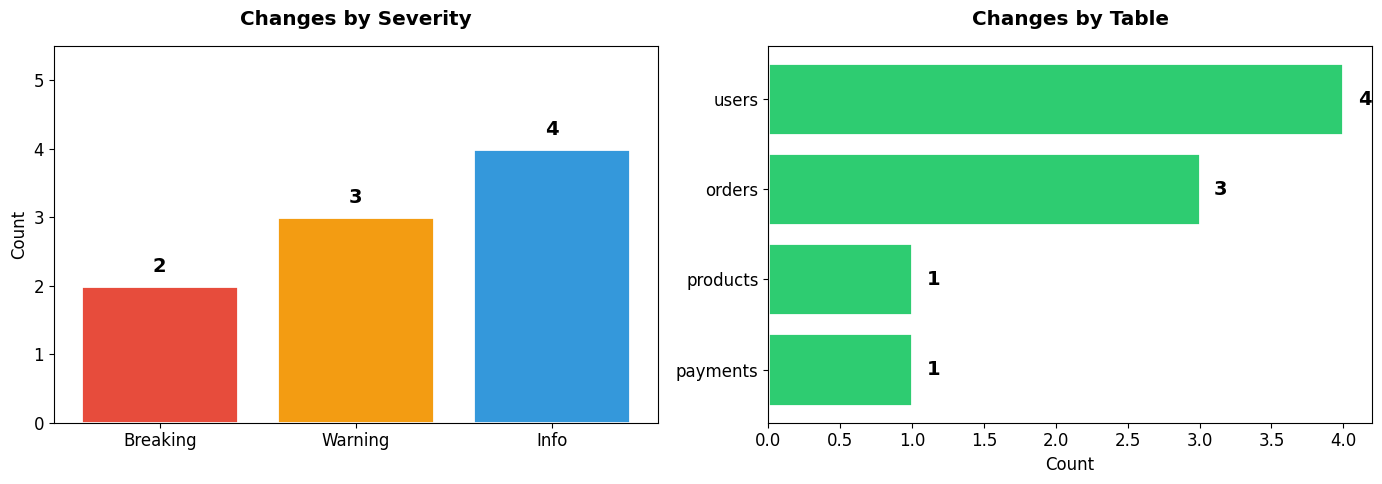

Chart saved to schema_diff_summary.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Changes by Severity ---
severities = ["Breaking", "Warning", "Info"]
counts = [breaking, warnings, info]
colors = ["#e74c3c", "#f39c12", "#3498db"]

bars = axes[0].bar(severities, counts, color=colors, edgecolor="white", linewidth=2)
axes[0].set_title("Changes by Severity", fontweight="bold", pad=15)
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(counts) + 1.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 str(count), ha="center", fontweight="bold", fontsize=14)

# --- Chart 2: Changes by Table ---
table_changes = {}
for c in changes:
    table_changes[c.table] = table_changes.get(c.table, 0) + 1

tables_sorted = sorted(table_changes.items(), key=lambda x: -x[1])
table_names = [t[0] for t in tables_sorted]
table_counts = [t[1] for t in tables_sorted]

bars2 = axes[1].barh(table_names, table_counts, color="#2ecc71", edgecolor="white", linewidth=2)
axes[1].set_title("Changes by Table", fontweight="bold", pad=15)
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()
for bar, count in zip(bars2, table_counts):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 str(count), va="center", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.savefig("schema_diff_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to schema_diff_summary.png")

---
## Step 8: Table Overview

In [8]:
all_tables = sorted(set(list(old_tables.keys()) + list(new_tables.keys())))

print(f"{'Table':<15} {'Status':<12} {'Changes':>8}")
print("-" * 38)

for t in all_tables:
    in_old = t in old_tables
    in_new = t in new_tables
    t_changes = [c for c in changes if c.table == t]

    if in_old and in_new:
        status = "modified" if t_changes else "unchanged"
    elif in_new:
        status = "NEW"
    else:
        status = "DROPPED"

    print(f"{t:<15} {status:<12} {len(t_changes):>8}")

Table           Status        Changes
--------------------------------------
orders          modified            3
payments        NEW                 1
products        DROPPED             1
users           modified            4


---
## Try Your Own Schemas

Replace the SQL below with your own `CREATE TABLE` statements and re-run the cells above!

In [9]:
# YOUR_OLD_SCHEMA = """
# CREATE TABLE my_table (
#     id INTEGER PRIMARY KEY,
#     name VARCHAR(100) NOT NULL
# );
# """
#
# YOUR_NEW_SCHEMA = """
# CREATE TABLE my_table (
#     id INTEGER PRIMARY KEY,
#     name VARCHAR(200),
#     email VARCHAR(255) NOT NULL
# );
# """
#
# my_old = parse_sql_schema(YOUR_OLD_SCHEMA)
# my_new = parse_sql_schema(YOUR_NEW_SCHEMA)
# my_changes = diff_schemas(my_old, my_new)
# for c in sorted(my_changes, key=lambda x: severity_order[x.severity]):
#     print(f"  {EMOJI[c.severity]} [{c.severity.upper():8s}]  {c.detail}")

---

**Built as Day 2 of the [FDE Portfolio Builder](https://github.com/phoebefu6/phoebe-the-builder)** — 60 mini AI products in 60 days.

For the interactive Streamlit version, run:
```bash
pip install streamlit
streamlit run app.py
```